In [1]:
import tensorflow as tf 
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt 

In [2]:
import numpy as np

In [3]:
Image_SIZE = 224
BATCH_SIZE = 32
channels = 3
EPOCHS = 30

In [4]:
dataset =  tf.keras.preprocessing.image_dataset_from_directory(
  "PlantVillage",
  shuffle=True,
  image_size=(Image_SIZE, Image_SIZE),
  batch_size = BATCH_SIZE 
  
)

Found 2152 files belonging to 3 classes.


In [5]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset)

68

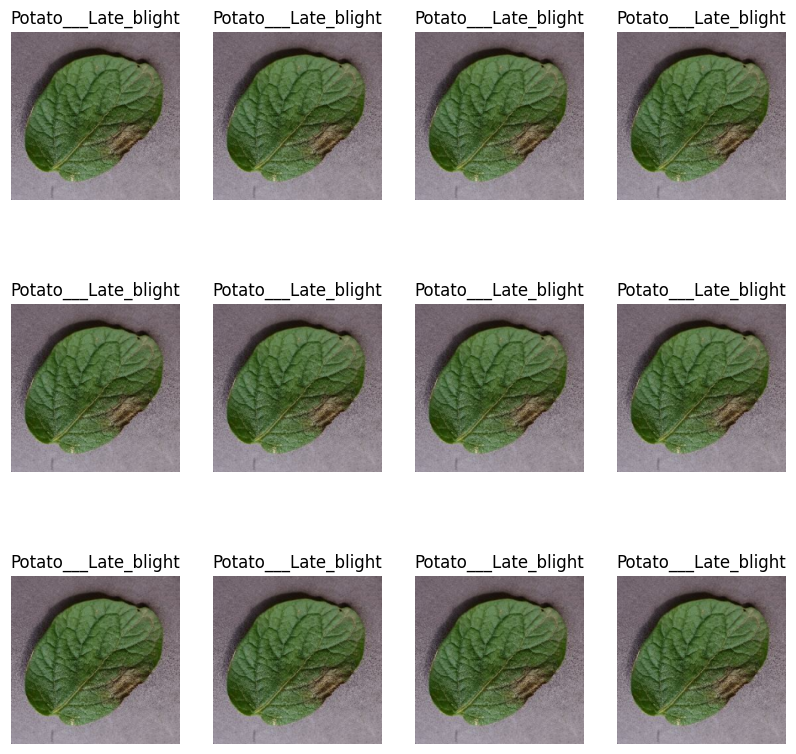

In [7]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
      ax =  plt.subplot(3, 4, i + 1)
      plt.imshow(image_batch[0].numpy().astype("uint8"))
      plt.title(class_names[label_batch[0]])
      plt.axis("off")

In [8]:
train_size = 0.8
dataset.take(10)
len(dataset)*train_size

54.400000000000006

In [9]:
train_ds = dataset.take(54)
len(train_ds)

54

In [10]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [11]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [12]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [13]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [14]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
  assert (train_split + test_split + val_split) == 1

  ds_size = len(ds)

  if shuffle:
    ds = ds.shuffle(shuffle_size, seed=12)

  train_size = int(train_split * ds_size)
  val_size = int(val_split * ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)

  return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds), len(val_ds), len(test_ds)

(54, 6, 8)

In [17]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) 
val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [22]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(Image_SIZE, Image_SIZE, channels),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(Image_SIZE, Image_SIZE, channels))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [27]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6
)


In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size = BATCH_SIZE,
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9769 - loss: 0.0669 - val_accuracy: 0.9740 - val_loss: 0.0550 - learning_rate: 0.0010
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9736 - loss: 0.0861 - val_accuracy: 0.9948 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9624 - loss: 0.1026 - val_accuracy: 0.9948 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9763 - loss: 0.0741 - val_accuracy: 0.9792 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9701 - loss: 0.0831 - val_accuracy: 0.9762 - val_loss: 0.0591 - learning_rate: 0.0010
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9830 - loss: 0.0493 - val_accuracy: 0.9740 - val_loss: 0.0565 - learning_rate: 3.0000e-04
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9759 - loss: 0.0618 - val_accur

In [30]:
base_model.trainable = True
 
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
 

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

fine_tune_epochs = 15
total_epochs = EPOCHS + fine_tune_epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 8/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.9161 - loss: 0.2366 - val_accuracy: 0.9583 - val_loss: 0.1115 - learning_rate: 1.0000e-05
Epoch 9/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9472 - loss: 0.1417 - val_accuracy: 0.9792 - val_loss: 0.0623 - learning_rate: 1.0000e-05
Epoch 10/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9513 - loss: 0.1333 - val_accuracy: 0.9792 - val_loss: 0.0495 - learning_rate: 1.0000e-05
Epoch 11/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9454 - loss: 0.1471 - val_accuracy: 0.9844 - val_loss: 0.0476 - learning_rate: 3.0000e-06
Epoch 12/45
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9484 - loss: 0.1231 - val_accuracy: 0.9821 - val_loss: 0.0952 - learning_rate: 3.0000e-06


In [32]:
scores = model.evaluate(test_ds)
print(f"Test accuracy: {scores[1]:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9688 - loss: 0.0826
Test accuracy: 0.9688


In [33]:
history

In [34]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 54}

In [35]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [36]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

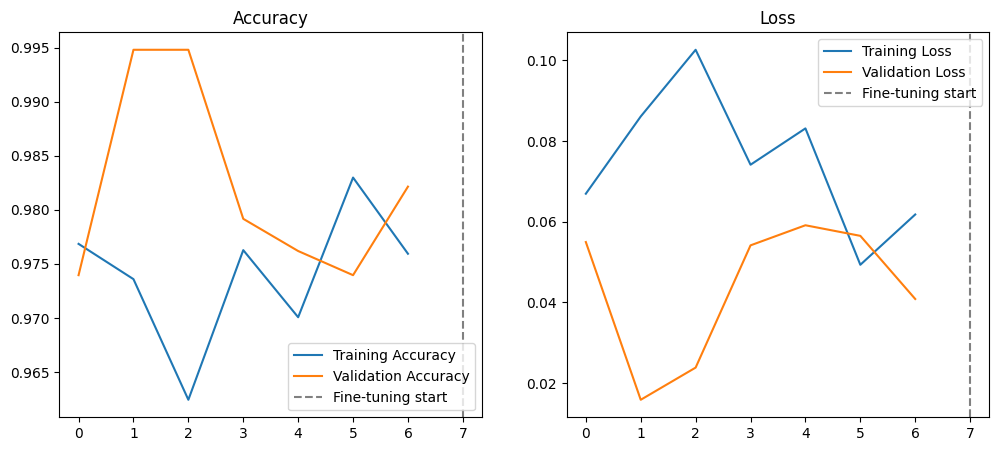

In [38]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.axvline(x=len(history.epoch), color="gray", linestyle="--", label="Fine-tuning start")
plt.legend(loc="lower right")
plt.title("Accuracy")
 
plt.subplot(1, 2, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.axvline(x=len(history.epoch), color="gray", linestyle="--", label="Fine-tuning start")
plt.legend(loc="upper right")
plt.title("Loss")
plt.show()
 

First image to predict
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
predicted label:  Potato___Early_blight


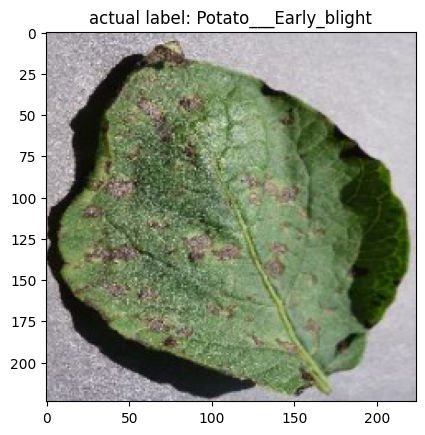

In [39]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = label_batch[0].numpy()
    print("First image to predict")
    plt.imshow(first_image)
    plt.title("actual label: " + class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print("predicted label: ", class_names[np.argmax(batch_prediction[0])])
    

In [40]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


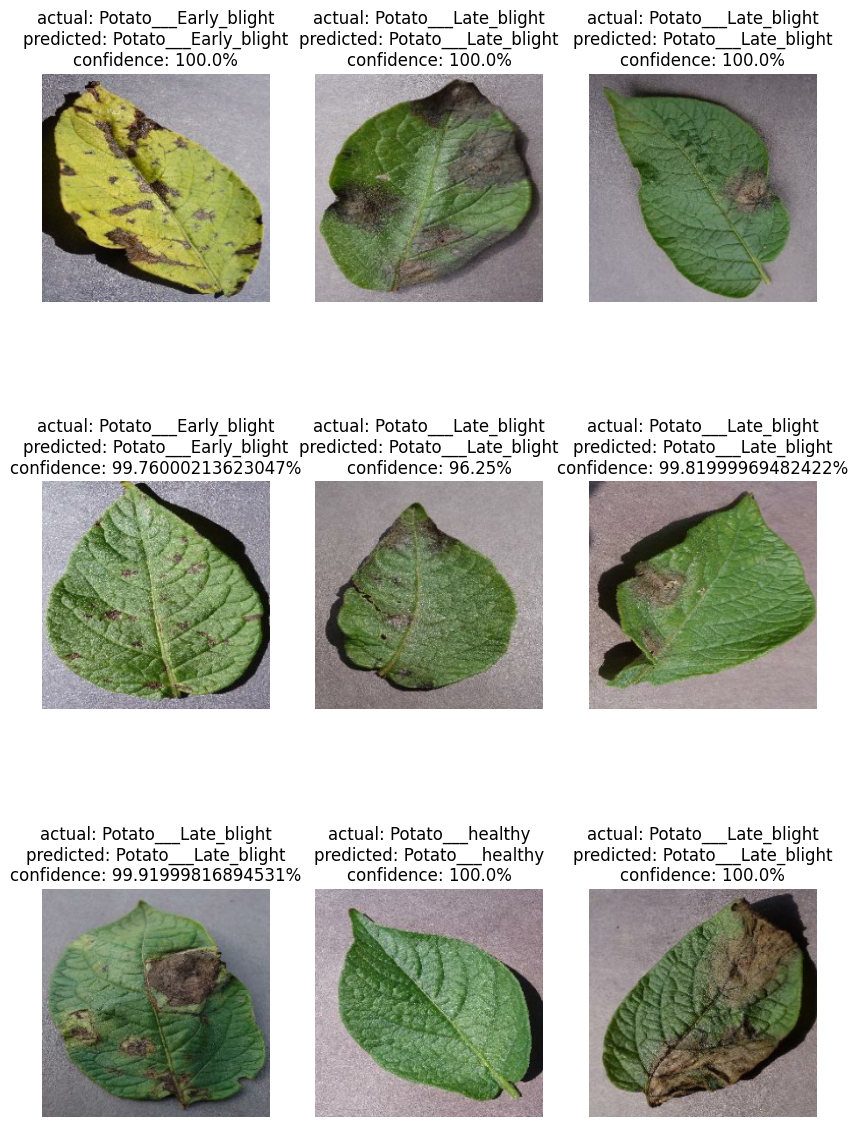

In [41]:
plt.figure(figsize=(10, 15))
for images , labels in test_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
        predicted_class, confidence = predict(model, images)
        actual_class = class_names[labels[i]]
        plt.title(f"actual: {actual_class}\npredicted: {predicted_class}\nconfidence: {confidence}%")
        

In [42]:
import os
 
model_version = max([int(x) for x in os.listdir("../models/potato_disease") + ["0"]] ) + 1 \
    if os.path.exists("../models/potato_disease") else 1
 
model.export(f"../models/potato_disease/{model_version}")
print(f"Done! SavedModel saved as version {model_version}.")
print("class_names order:", class_names)
 





INFO:tensorflow:Assets written to: ../models/potato_disease/2\assets


INFO:tensorflow:Assets written to: ../models/potato_disease/2\assets


Saved artifact at '../models/potato_disease/2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2319407203920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2321421105680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319407204688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319407205072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319407203728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319407204112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319430813072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319430814224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319430815184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319430814800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2319430813840: Tenso